# Minicurso de Machine Learning: Previsão de Preços de Imóveis
Neste notebook, vamos passar por todas as etapas de um projeto de Machine Learning simples:
1. Análise Exploratória de Dados (EDA)
2. Pré-processamento
3. Treinamento de Modelos
4. Avaliação e Comparação
5. Exportação do Melhor Modelo

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os

# Configurações visuais
sns.set_theme(style="whitegrid")

# formatação para números float -- evita notação científica
pd.set_option("display.float_format", lambda x: "%.2f" % x)

## 1. Carregamento e Análise Exploratória de Dados (EDA)

In [ ]:
# Carregando o dataset
# Como o notebook está na pasta notebooks/ e o dado em data/, usamos o caminho relativo
data_path = "../data/houses.csv"
df = pd.read_csv(data_path)

# Visualizando as primeiras linhas
# DESAFIO 1: Descomente a linha abaixo para visualizar as primeiras linhas do dataset
# df.head()


,area_m2,quartos,banheiros,vagas,idade_anos,preco
0,144,2,2,1,15,763304.37
1,113,2,2,1,8,744438.38
2,152,3,4,1,19,858876.67
3,196,2,2,1,3,1009228.51
4,108,2,2,0,36,645650.92


In [3]:
# Informações gerais sobre os dados
# DESAFIO 2: Descomente para ver as informações gerais dos dados
# df.info()


<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   area_m2     5000 non-null   int64  
 1   quartos     5000 non-null   int64  
 2   banheiros   5000 non-null   int64  
 3   vagas       5000 non-null   int64  
 4   idade_anos  5000 non-null   int64  
 5   preco       5000 non-null   float64
dtypes: float64(1), int64(5)
memory usage: 234.5 KB


In [4]:
# Estatísticas descritivas
# DESAFIO 3: Descomente para ver as estatísticas descritivas
# df.describe()


,area_m2,quartos,banheiros,vagas,idade_anos,preco
count,5000.000000,5000.000000,5000.00000,5000.000000,5000.00000,5.000000e+03
mean,120.984000,2.734600,2.83640,1.436800,14.92860,7.622144e+05
std,47.356244,0.972806,1.07474,1.072117,9.39029,2.613146e+05
min,40.000000,1.000000,1.00000,0.000000,0.00000,2.398484e+05
25%,87.000000,2.000000,2.00000,1.000000,8.00000,5.749351e+05
50%,120.000000,3.000000,3.00000,1.000000,15.00000,7.492444e+05
75%,153.000000,3.000000,4.00000,2.000000,21.00000,9.209598e+05
max,316.000000,5.000000,5.00000,4.000000,54.00000,2.349910e+06


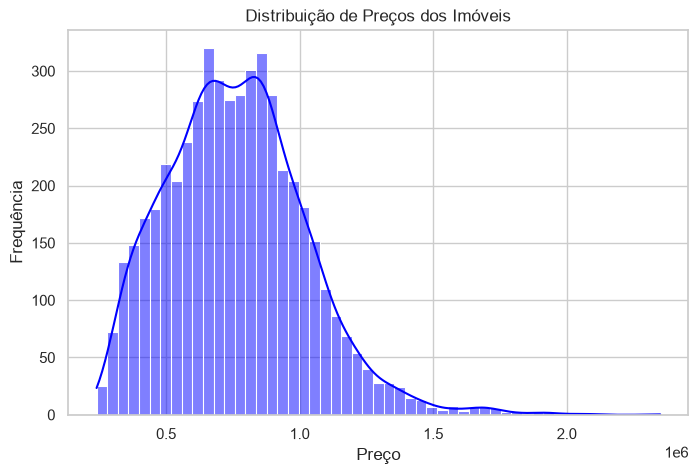

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(df["preco"], kde=True, color="blue")
plt.title("Distribuição de Preços dos Imóveis")
plt.xlabel("Preço")
plt.ylabel("Frequência")
plt.show()

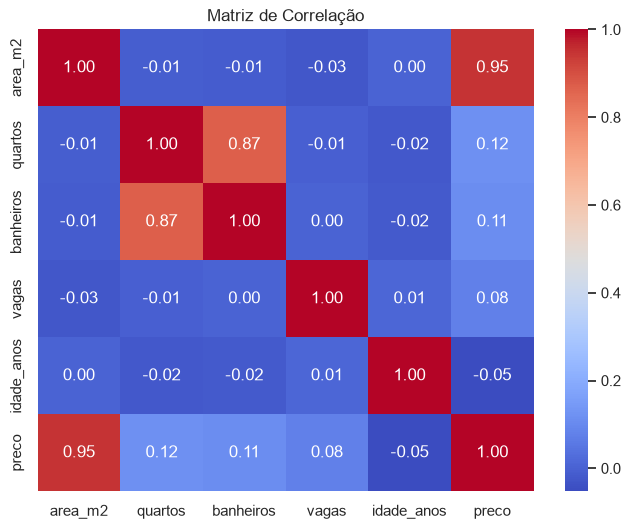

In [ ]:
plt.figure(figsize=(8, 6))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de Correlação")
plt.show()

## 2. Preparação dos Dados e Divisão de Treino/Teste

In [ ]:
from sklearn.model_selection import train_test_split

# Separando features (X) e target (y)
X = df.drop(columns=["preco"])
y = df["preco"]

# Dividindo em treino (80%) e teste (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Treino: {X_train.shape[0]} amostras")
print(f"Teste: {X_test.shape[0]} amostras")

Treino: 4000 amostras
Teste: 1000 amostras


## 3. Treinamento e Avaliação de Modelos
Vamos treinar dois modelos: uma Regressão Linear simples e um Random Forest.

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# Função auxiliar para avaliar
def avaliar_modelo(nome, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"--- {nome} ---")
    print(f"MAE:  {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R²:   {r2:.4f}\n")
    return rmse

In [ ]:
# DESAFIO 4: Descomente as linhas abaixo para treinar e avaliar a Regressão Linear
# Modelo 1: Regressão Linear
# lr_model = LinearRegression()
# lr_model.fit(X_train, y_train)
# lr_preds = lr_model.predict(X_test)
# rmse_lr = avaliar_modelo("Regressão Linear", y_test, lr_preds)

--- Regressão Linear ---
MAE:  50881.36
RMSE: 71661.72
R²:   0.9253



In [ ]:
# Modelo 2: Random Forest (com otimização de hiperparâmetros)
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
}

rf_base = RandomForestRegressor(random_state=42)
grid_search = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    cv=3,
    n_jobs=-1,
    scoring="neg_root_mean_squared_error",
)
grid_search.fit(X_train, y_train)

rf_model = grid_search.best_estimator_
print(f"Melhores parâmetros: {grid_search.best_params_}")

rf_preds = rf_model.predict(X_test)
rmse_rf = avaliar_modelo("Random Forest (Otimizado)", y_test, rf_preds)

Melhores parâmetros: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}
--- Random Forest (Otimizado) ---
MAE:  52108.04
RMSE: 69977.96
R²:   0.9287



## Comparação: Previsto vs Realizado

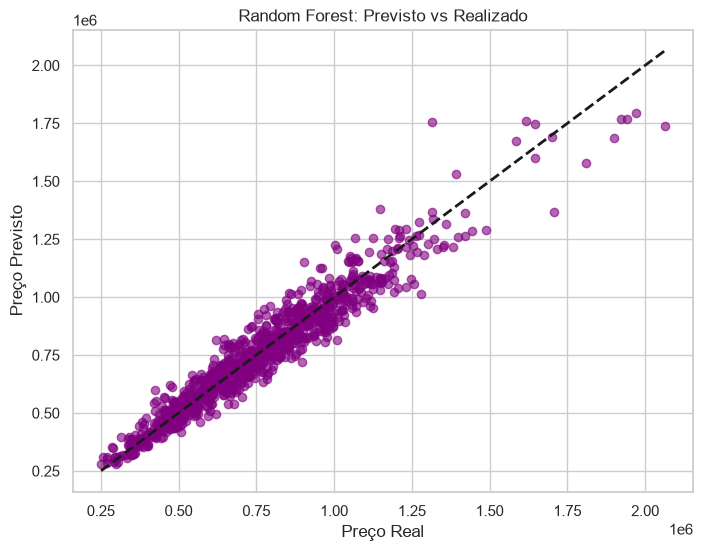

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, rf_preds, alpha=0.6, color="purple")
# Linha ideal
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "k--", lw=2)
plt.title("Random Forest: Previsto vs Realizado")
plt.xlabel("Preço Real")
plt.ylabel("Preço Previsto")
plt.show()

O Random Forest lidou bem com as variáveis.
Vamos exportá-lo como o nosso modelo oficial para a API.

## 4. Exportando o Modelo (Serialização)
Vamos salvar o modelo e o RMSE do teste. O RMSE será usado na nossa API para calcular um 'intervalo de confiança' (sugestão de preço ± RMSE) de forma simplificada.

In [ ]:
# Preparando um dicionário com o modelo e metadados
modelo_exportacao = {
    "model": rf_model,
    "features": list(X.columns),
    "rmse_teste": rmse_rf,
}

# Salvando o modelo na pasta models/
os.makedirs("../models", exist_ok=True)
caminho_modelo = "../models/modelo_imoveis.pkl"

# DESAFIO 5: Descomente as linhas abaixo para salvar o modelo em disco (.pkl)
# with open(caminho_modelo, "wb") as f:
#     pickle.dump(modelo_exportacao, f)

# print(f"Modelo salvo com sucesso em {caminho_modelo}")

Modelo salvo com sucesso em ../models/modelo_imoveis.pkl


In [ ]:
# Testando o carregamento do modelo
with open(caminho_modelo, "rb") as f:
    modelo_carregado = pickle.load(f)

print("As features esperadas pelo modelo são:", modelo_carregado["features"])
print("RMSE armazenado:", modelo_carregado["rmse_teste"])

As features esperadas pelo modelo são: ['area_m2', 'quartos', 'banheiros', 'vagas', 'idade_anos']
RMSE armazenado: 69977.95661219668
